<a href="https://colab.research.google.com/github/karthik-1219/IPL-Data-Analysis-Project/blob/main/IPL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import essential libraries
import pandas as pd          # Data handling
import numpy as np           # Numerical operations
import seaborn as sns        # Data visualization
import matplotlib.pyplot as plt  # Plotting


In [ ]:
# Set plot styles
sns.set_style('whitegrid')       # Seaborn plot style
plt.style.use('fivethirtyeight') # Matplotlib plot style


In [ ]:
# Load datasets
deli = pd.read_csv('/content/deliveries.csv')  # Delivery-level data
mat = pd.read_csv('/content/matches.csv')      # Match summary data


In [ ]:
# Check shape of deliveries dataset (rows, columns)
deli.shape


(260920, 17)

In [ ]:
# Display first 3 rows of the deliveries dataset
deli.head(3)


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [ ]:
# Check shape of matches dataset (rows, columns)
mat.shape


(1095, 20)

In [ ]:
# Display first 3 rows of the matches dataset
mat.head(3)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar


In [ ]:
# Count occurrences of each team in the 'team1' column
mat['team1'].value_counts()


,count
team1,
Royal Challengers Bangalore,135
Chennai Super Kings,128
Mumbai Indians,123
Kolkata Knight Riders,121
Rajasthan Royals,101
Kings XI Punjab,92
Sunrisers Hyderabad,86
Delhi Daredevils,85
Delhi Capitals,41


In [ ]:
# Check team name variations or inconsistencies in 'batting_team' column
deli['batting_team'].value_counts()


,count
batting_team,
Mumbai Indians,31437
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Royal Challengers Bangalore,28205
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


In [ ]:
# Standardize team names in 'batting_team' and 'bowling_team' columns

deli['batting_team'] = deli['batting_team'].replace({'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'})
deli['bowling_team'] = deli['bowling_team'].replace({'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'})

deli['batting_team'] = deli['batting_team'].replace({'Rising Pune Supergiant': 'Rising Pune Supergiants'})
deli['bowling_team'] = deli['bowling_team'].replace({'Rising Pune Supergiant': 'Rising Pune Supergiants'})


In [ ]:
# Display first 3 rows of the updated deliveries dataset
deli.head(3)


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [ ]:
# Verify updated team name counts in 'batting_team' column
deli['batting_team'].value_counts()


,count
batting_team,
Mumbai Indians,31437
Royal Challengers Bengaluru,30023
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


In [ ]:
# Resolve naming issues in matches.csv: standardize city, venue, and team names

# Replace inconsistent city names
city_replacements = {
    'Bangalore': 'Bengaluru',
    'Chandigarh': 'Mohali',
    'Navi Mumbai': 'Mumbai'
}
mat['city'] = mat['city'].replace(city_replacements)

# Replace inconsistent venue names
venue_replacements = {
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'Punjab Cricket Association Stadium',
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam': 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium',
    'Barsapara Cricket Stadium, Guwahati': 'Barsapara Cricket Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'Himachal Pradesh Cricket Association Stadium',
    'Vidarbha Cricket Association Stadium, Jamtha': 'Vidarbha Cricket Association Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur': 'Maharaja Yadavindra Singh International Cricket Stadium',
}
mat['venue'] = mat['venue'].replace(venue_replacements)

# Replace inconsistent team names across multiple columns
team_replacements = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}
for i in ['team1', 'team2', 'toss_winner', 'winner']:
    mat[i] = mat[i].replace(team_replacements)


In [ ]:
# Display first 5 rows of the updated matches dataset
mat.head()


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bengaluru,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Mohali,2008-04-19,League,MEK Hussey,Punjab Cricket Association Stadium,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
# Count total missing (NA) values in the 'city' column
mat['city'].isna().sum()


np.int64(51)

In [ ]:
# Fill missing values in 'city' column with 'Unknown'
mat['city'] = mat['city'].fillna('Unknown')


In [ ]:
# Check how many matches used the Duckworth-Lewis (D/L) method
mat['method'].value_counts()


,count
method,
D/L,21


In [ ]:
# Replace missing values in 'method' column with 'Non D/L'
mat['method'] = mat['method'].fillna('Non D/L')


In [ ]:
# Function to generate a list of random hex color codes
def random_colors(no_of_colors):
    return ['#'+''.join([np.random.choice(list('0123456789ABCDEF')) for _ in range(6)]) for _ in range(no_of_colors)]


**Success Rate of IPL Teams (Win Percentage till 2024)**

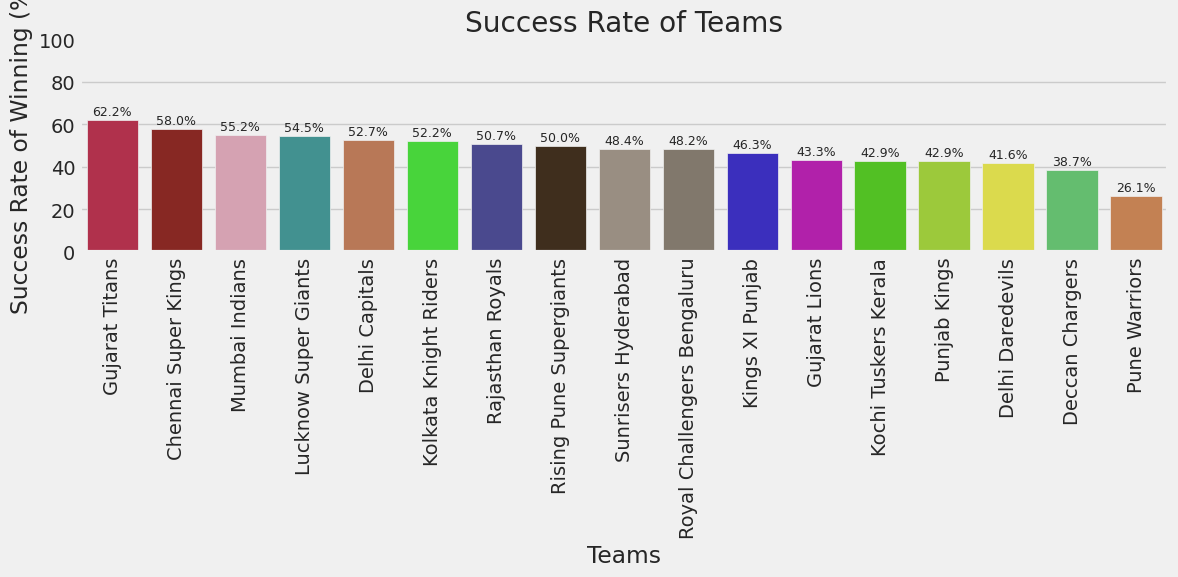

In [ ]:
# Calculate number of wins for each team
wins = mat['winner'].value_counts()

# Calculate total matches played by each team (as team1 + team2)
matches_played = mat['team1'].value_counts() + mat['team2'].value_counts()

# Compute success rate as (wins / matches played) * 100
sr = (wins / matches_played) * 100

# Sort the success rate in descending order
sr = sr.sort_values(ascending=False)

# Set figure size and plot success rate as barplot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=sr.index, y=sr.values, hue=sr.index, palette=random_colors(len(sr)), legend=False)

# Set plot titles and labels
plt.title('Success Rate of Teams')
plt.xlabel('Teams')
plt.ylabel('Success Rate of Winning (%)')
plt.xticks(rotation=90)
plt.ylim(0, 100)

# Add percentage labels on top of bars
for i, v in enumerate(sr.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


**IPL Titles Won by Each Team (Till 2024)**

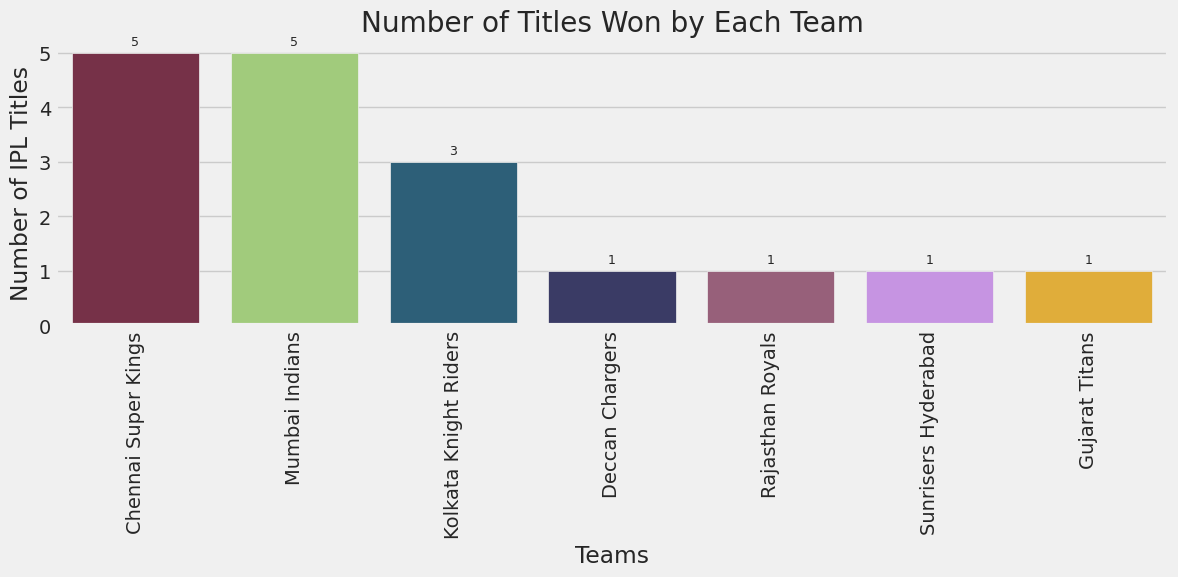

In [ ]:
# Get winner count by selecting the last match winner of each season (final match winner)
wc = mat.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()

# Set figure size for the plot
plt.figure(figsize=(12, 6))

# Plot number of titles won using barplot
ax = sns.barplot(x=wc.index, y=wc.values, hue=wc.index, palette=random_colors(len(wc)), legend=False)

# Set plot titles and labels
plt.title('Number of Titles Won by Each Team')
plt.xlabel('Teams')
plt.ylabel('Number of IPL Titles')
plt.xticks(rotation=90)

# Add count labels above each bar
for i, v in enumerate(wc.values):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=9)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


**Top 10 Highest Run Scorers in IPL (Till 2024)**

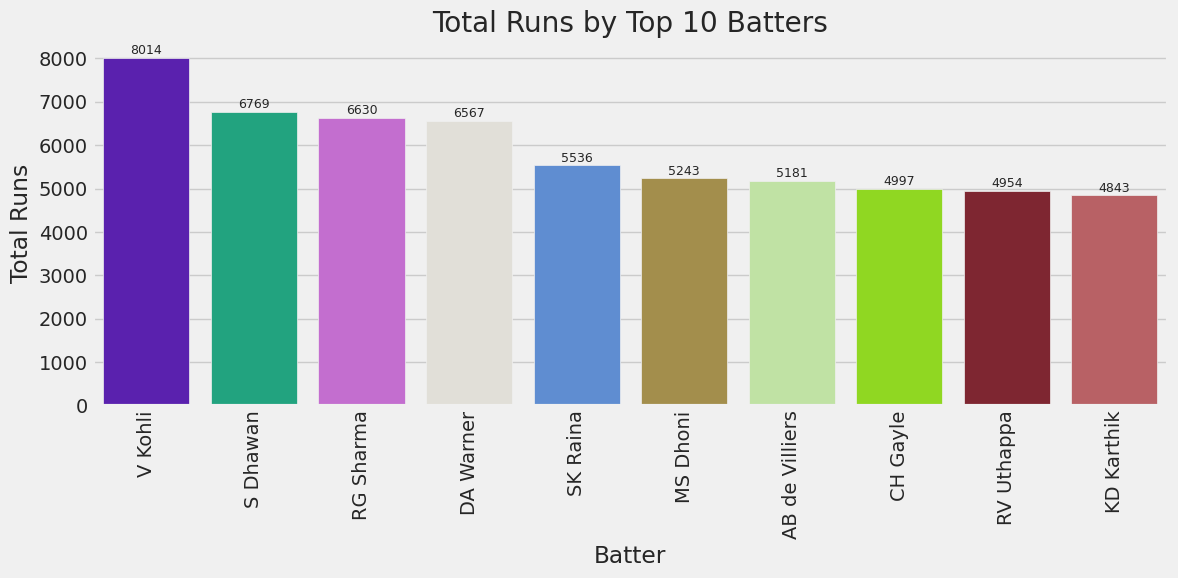

In [ ]:
# Calculate total runs scored by each batter
tot_runs = deli.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')

# Get top 10 run scorers
top10_runs = tot_runs.sort_values(by='Runs', ascending=False).head(10)

# Set figure size for the plot
plt.figure(figsize=(12, 6))

# Plot top 10 batters with total runs using barplot
ax = sns.barplot(x='batter', y='Runs', hue='batter', data=top10_runs, palette=random_colors(len(top10_runs)), legend=False)

# Set plot title and axis labels
plt.title('Total Runs by Top 10 Batters')
plt.xlabel('Batter')
plt.ylabel('Total Runs')
plt.xticks(rotation=90)

# Add value labels above each bar
for i, v in enumerate(top10_runs['Runs']):
    ax.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=9)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [ ]:
# Calculate runs scored by each batter in individual innings
ings_runs = deli.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')

# Get top 10 highest individual innings scores
top10_ings_runs = ings_runs.sort_values(by='Innings Runs', ascending=False).head(10)


**Top 10 Individual Batting Performances in IPL Matches – Runs vs Strike Rate**

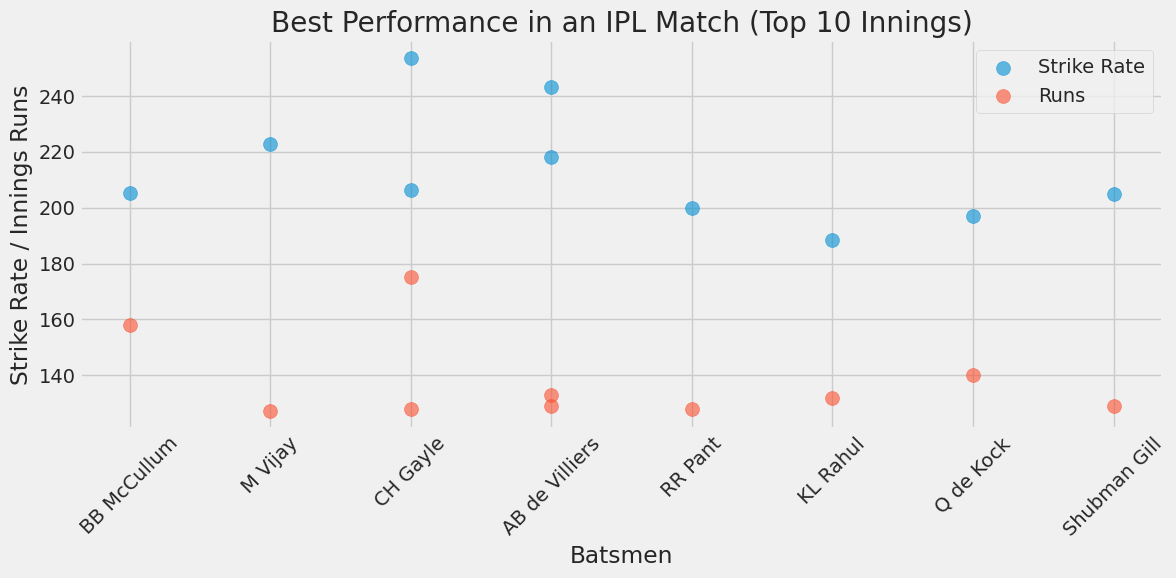

In [ ]:
# Count number of balls faced by each batter in each match
balls_faced = deli.groupby(['match_id', 'batter'])['batsman_runs'].count().reset_index(name='Balls Faced')

# Merge innings runs and balls faced to calculate strike rate
bm_perf = pd.merge(ings_runs, balls_faced, how='inner', on=['match_id', 'batter'])

# Compute strike rate for each match (Innings Runs * 100 / Balls Faced)
bm_perf['Strike Rate for Match'] = np.round(bm_perf['Innings Runs'] * 100 / bm_perf['Balls Faced'], 2)

# Filter only top 10 individual performances from earlier step
bm_perf_top10 = bm_perf[bm_perf.set_index(['match_id', 'batter']).index.isin(top10_ings_runs.set_index(['match_id', 'batter']).index)]

# Plot: Scatter chart comparing strike rate and innings runs for top 10 performances
plt.figure(figsize=(12, 6))
plt.scatter(bm_perf_top10['batter'], bm_perf_top10['Strike Rate for Match'], label='Strike Rate', s=100, alpha=0.6)
plt.scatter(bm_perf_top10['batter'], bm_perf_top10['Innings Runs'], label='Runs', s=100, alpha=0.6)
plt.title('Best Performance in an IPL Match (Top 10 Innings)')
plt.xlabel('Batsmen')
plt.ylabel('Strike Rate / Innings Runs')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Top 10 Bowlers in IPL History (Till 2020)**

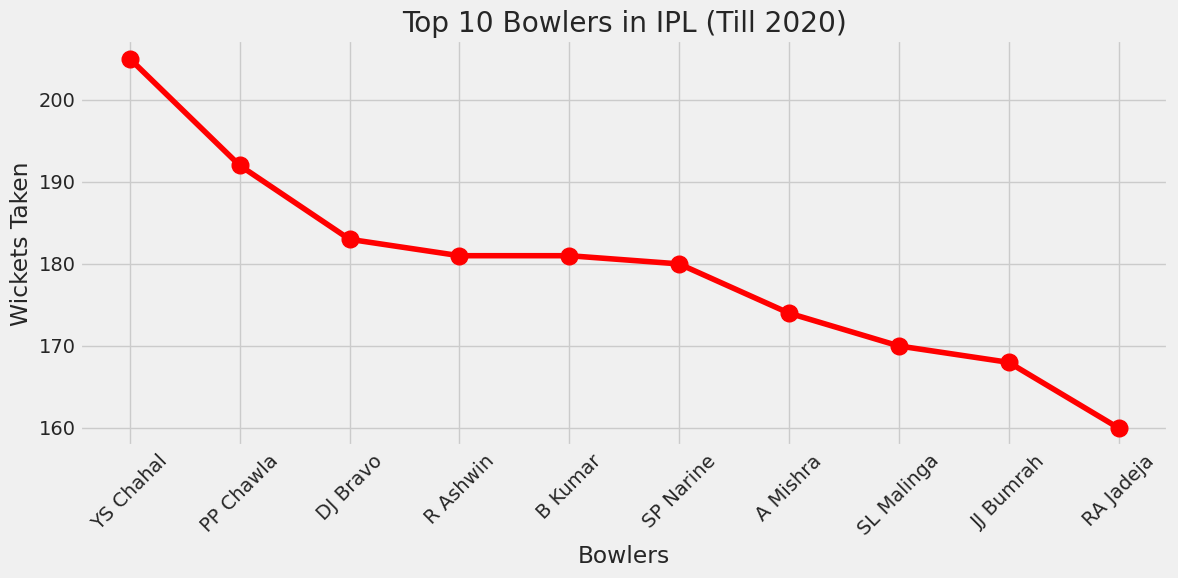

In [ ]:
# Filter out 'run out' dismissals to count only valid bowling dismissals
bw = deli[deli['dismissal_kind'] != 'run out']

# Group by bowler and count number of dismissals as wickets
top_bwlrs = bw.groupby('bowler')['dismissal_kind'].count().reset_index(name='wickets')

# Sort the bowlers by wicket count in descending order and select top 10
top_bwlrs = top_bwlrs.sort_values(by='wickets', ascending=False).head(10)

# Set the figure size for the plot
plt.figure(figsize=(12, 6))

# Create a line plot with red markers showing top 10 bowlers and their wicket counts
plt.plot(top_bwlrs['bowler'], top_bwlrs['wickets'], marker='o', color='red', ms=12)

# Set title and axis labels
plt.title('Top 10 Bowlers in IPL (Till 2020)')
plt.xlabel('Bowlers')
plt.ylabel('Wickets Taken')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()


**IPL Best Bowling Performances in a Match (Till 2024)**

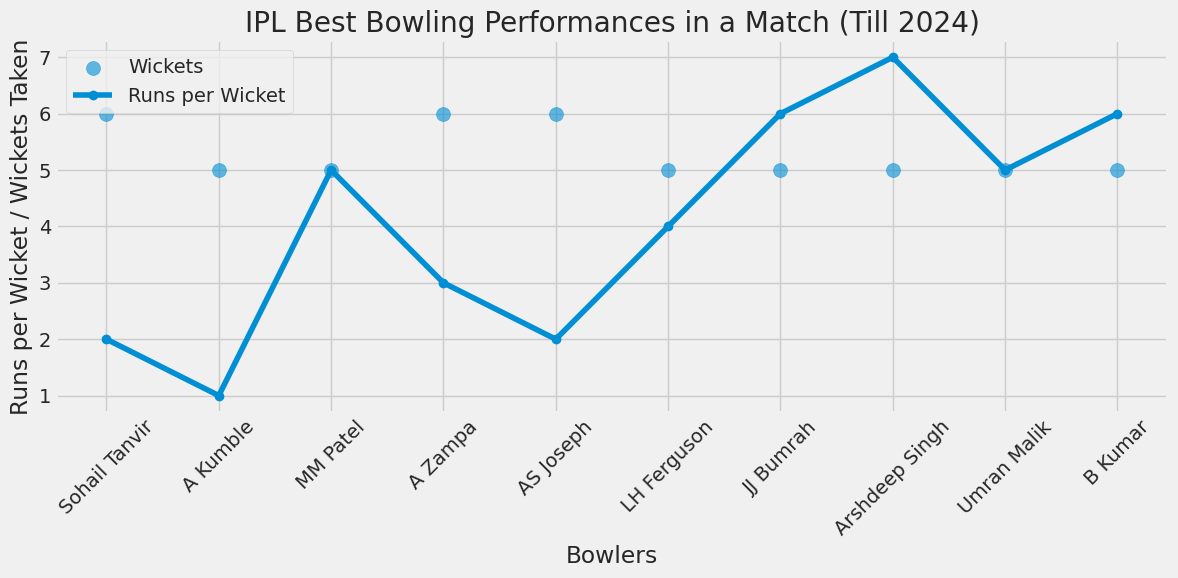

In [ ]:
# 🔹 Step 1: Filter out valid bowling dismissals (excluding 'run out')
# (Already done previously and stored in `bw`)

# 🔹 Step 2: Count number of wickets taken by each bowler in each match
bw_wickets = bw.groupby(['match_id', 'bowler'])['dismissal_kind'] \
               .count() \
               .reset_index(name='wickets') \
               .sort_values(by='wickets', ascending=False)[:10]  # Top 10 bowling performances

# 🔹 Step 3: Sum the runs conceded by each bowler in each match
bw_runs = deli.groupby(['match_id', 'bowler'])['total_runs'] \
              .sum() \
              .reset_index(name='runs_conceded')

# 🔹 Step 4: Merge both datasets to analyze both runs conceded and wickets taken
bw_perf = pd.merge(bw_runs, bw_wickets, how='inner', on=['match_id', 'bowler'])

# 🔹 Step 5: Calculate Runs Per Wicket for each bowler in that match
bw_perf['runs_per_wicket'] = np.round(bw_perf['runs_conceded'] / bw_perf['wickets'], 0)

# 🔹 Step 6: Plotting the data
plt.figure(figsize=(12, 6))

# Scatter plot for number of wickets taken
plt.scatter(bw_perf['bowler'], bw_perf['wickets'],
            label='Wickets', s=100, alpha=0.6)

# Line plot for runs per wicket
plt.plot(bw_perf['bowler'], bw_perf['runs_per_wicket'],
         marker='o', label='Runs per Wicket')

# Chart formatting
plt.title('IPL Best Bowling Performances in a Match (Till 2024)')
plt.xlabel('Bowlers')
plt.ylabel('Runs per Wicket / Wickets Taken')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()


**Merge Delivery and Match Data to Include Season Information**

In [ ]:
# 🔹 Step 1: Rename 'id' column in match dataframe to 'match_id' for consistent merging
mat = mat.rename(columns={'id': 'match_id'})

# 🔹 Step 2: Merge 'deli' (deliveries) with 'mat' (matches) to attach 'season' info to each ball
# This adds the season to each delivery based on the match_id
deli_season = deli.merge(mat[['match_id', 'season']], on='match_id', how='left')


**Top Wicket Taker Per IPL Season (Excluding Run Outs)**

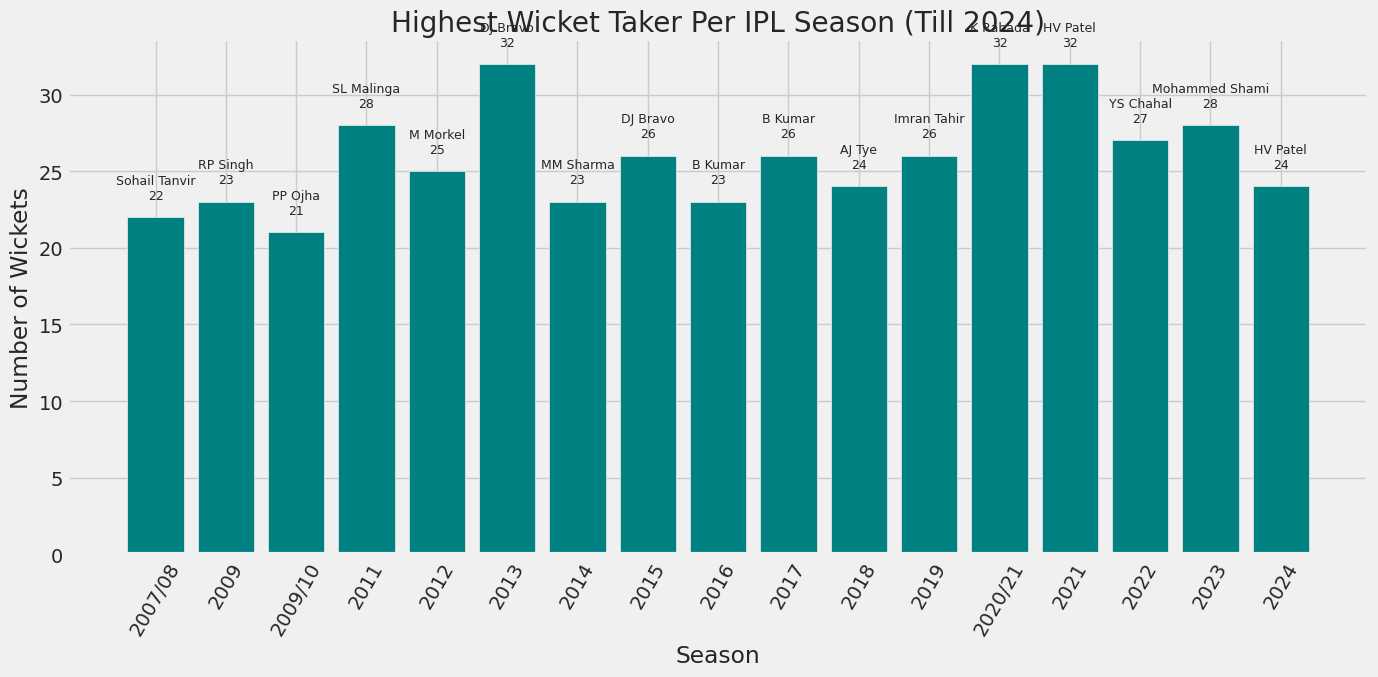

In [ ]:
# Merge the season information from match dataset into deliveries dataset
mat = mat.rename(columns={'id': 'match_id'})
deli_season = deli.merge(mat[['match_id', 'season']], on='match_id', how='left')

# Remove 'run out' as it's not credited to the bowler
wickets = deli_season[deli_season['dismissal_kind'] != 'run out']

# Count number of wickets per bowler per season
season_bowler_wickets = wickets.groupby(['season', 'bowler'])['dismissal_kind'].count().reset_index(name='wickets')

# Get the bowler with maximum wickets in each season
top_wicket_takers = season_bowler_wickets.loc[season_bowler_wickets.groupby('season')['wickets'].idxmax()]

# Plotting: Highest Wicket Taker Per IPL Season
plt.figure(figsize=(14, 7))
bars = plt.bar(top_wicket_takers['season'].astype(str), top_wicket_takers['wickets'], color='teal')
plt.title('Highest Wicket Taker Per IPL Season (Till 2024)')
plt.xlabel('Season')
plt.ylabel('Number of Wickets')
plt.xticks(rotation=60)

# Annotate each bar with bowler name and wickets taken
for bar, bowler, wickets in zip(bars, top_wicket_takers['bowler'], top_wicket_takers['wickets']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{bowler}\n{wickets}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**Highest Wickets in a Single Match Per IPL Season (Till 2024)**

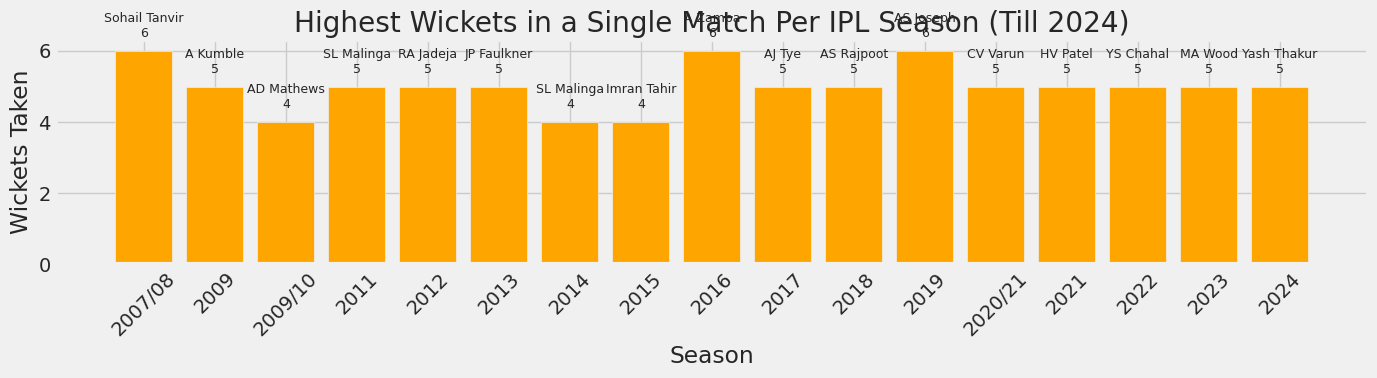

In [ ]:
# Filter out 'run out' dismissals as they are not credited to bowlers
bw_wkts = deli[deli['dismissal_kind'] != 'run out']

# Count wickets by each bowler per match
bw_match = bw_wkts.groupby(['match_id', 'bowler'])['dismissal_kind'].count().reset_index(name='wkts')

# Merge with season information from match dataset
bw_match = pd.merge(bw_match, mat[['match_id', 'season']], on='match_id', how='left')

# Sort to get highest wicket haul in each season
bw_max_match = bw_match.sort_values(['season', 'wkts'], ascending=[True, False])
bw_max_match = bw_max_match.groupby('season').head(1).reset_index(drop=True)

# Plotting the top wicket-taking performance per season
plt.figure(figsize=(14, 4))
bars = plt.bar(bw_max_match['season'].astype(str), bw_max_match['wkts'], color='orange')
plt.title('Highest Wickets in a Single Match Per IPL Season (Till 2024)')
plt.xlabel('Season')
plt.ylabel('Wickets Taken')
plt.xticks(rotation=45)

# Annotate each bar with bowler name and wickets
for bar, bowler, wkts in zip(bars, bw_max_match['bowler'], bw_max_match['wkts']):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{bowler}\n{wkts}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
mat.columns


Index(['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

**Most Centuries in a Season - IPL (Till 2024)**

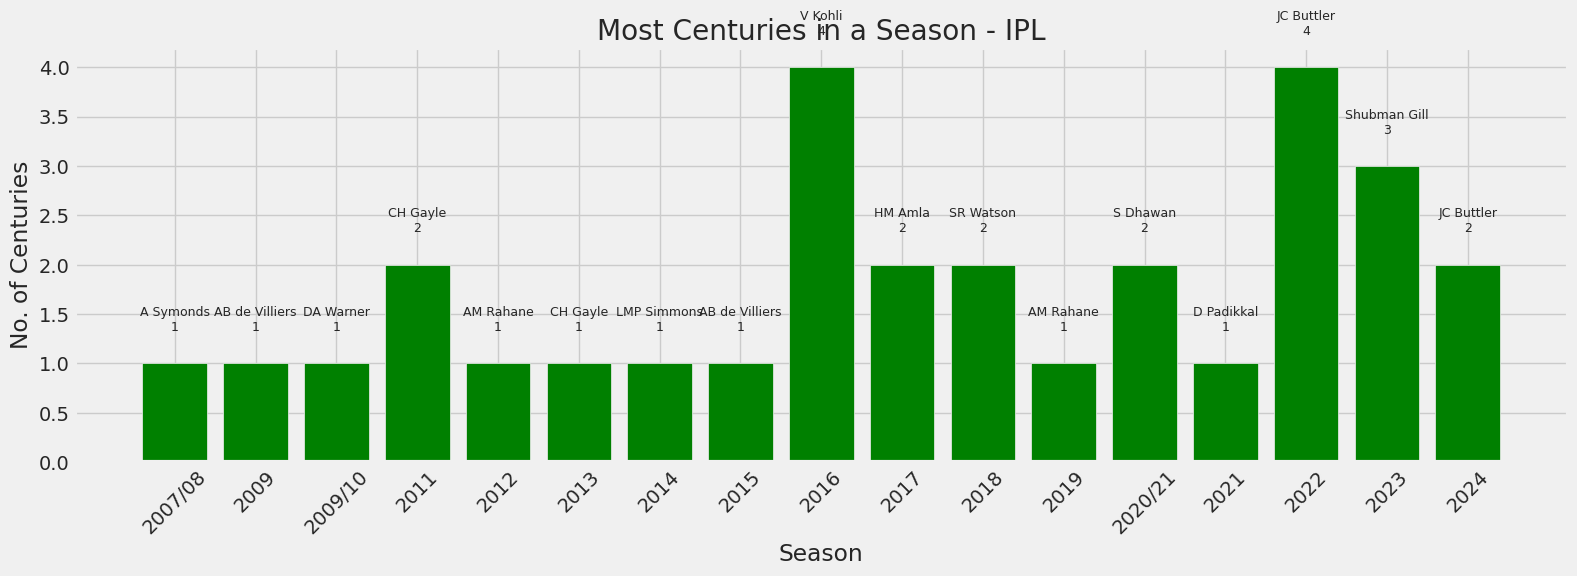

In [ ]:
# Grouping by match and batter to calculate total runs per match per player
# Helps identify individual high-scoring innings
bat_runs = deli.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index(name='runs')

# Filtering innings where the batter scored 100 or more runs (centuries)
centuries = bat_runs[bat_runs['runs'] >= 100]

# Adding season information by merging with match dataset
centuries = centuries.merge(mat[['match_id', 'season']], on='match_id', how='left')

# Counting number of centuries per batter per season
cent_by_season = centuries.groupby(['season', 'batter']).size().reset_index(name='centuries')

# Sorting to find the player with the most centuries per season
max_cent = cent_by_season.sort_values(['season', 'centuries'], ascending=[True, False])
max_cent = max_cent.groupby('season').head(1).reset_index(drop=True)

# Plotting the highest century scorer in each season as a bar chart
plt.figure(figsize=(16,6))
bars = plt.bar(max_cent['season'].astype(str), max_cent['centuries'], color='green')
plt.title('Most Centuries in a Season - IPL')
plt.xlabel('Season')
plt.ylabel('No. of Centuries')
plt.xticks(rotation=45)

# Adding text labels above bars showing player name and number of centuries
for bar, name, ct in zip(bars, max_cent['batter'], max_cent['centuries']):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{name}\n{ct}", ha='center', va='bottom', fontsize=9)

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


**Most Consistent Batter (Highest Batting Average among Top Scorers)**

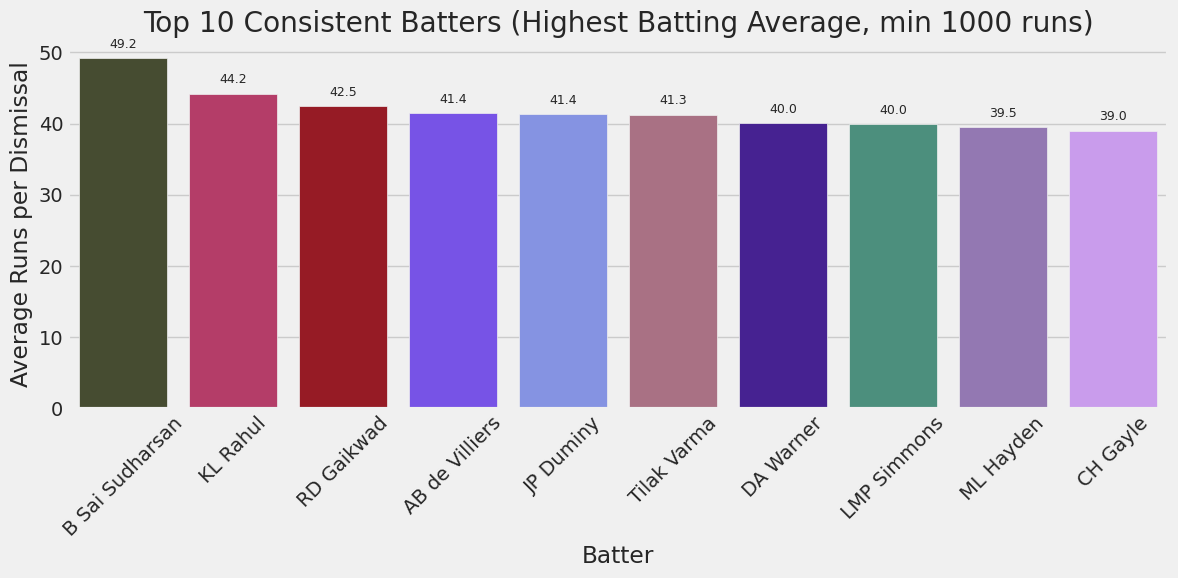

In [ ]:
# Dismissals per batter
dismissals = deli[deli['is_wicket'] == 1].groupby('batter')['is_wicket'].count()

# Total runs per batter
runs_scored = deli.groupby('batter')['batsman_runs'].sum()

# Calculate batting average (Runs / Dismissals)
bat_avg = (runs_scored / dismissals).dropna().reset_index(name='Average')
bat_avg = bat_avg[bat_avg['Average'] < 100]  # Remove anomalies

# Select batters with minimum 1000 runs
valid_batters = runs_scored[runs_scored >= 1000].index
bat_avg = bat_avg[bat_avg['batter'].isin(valid_batters)]

# Top 10 averages
top_avg = bat_avg.sort_values(by='Average', ascending=False).head(10)

# Plot
plt.figure(figsize=(12,6))
ax = sns.barplot(x='batter', y='Average', hue='batter', data=top_avg, palette=random_colors(len(top_avg)), legend=False)
plt.title('Top 10 Consistent Batters (Highest Batting Average, min 1000 runs)')
plt.xlabel('Batter')
plt.ylabel('Average Runs per Dismissal')
plt.xticks(rotation=45)

# Add labels
for i, v in enumerate(top_avg['Average']):
  ax.text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**Best Economy Bowlers (Min 500 balls bowled)**

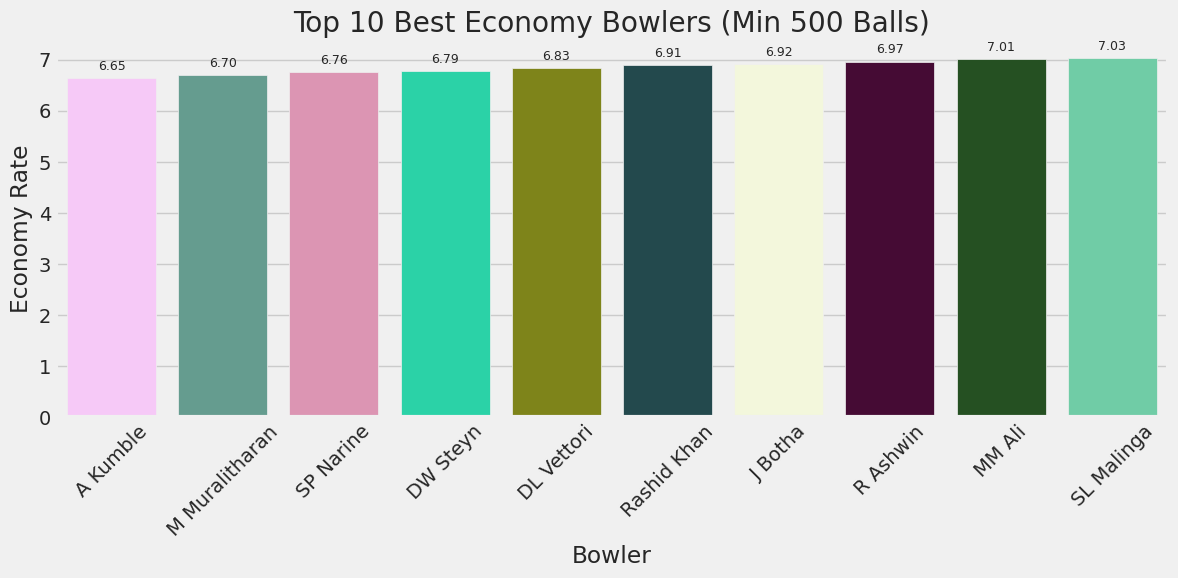

In [ ]:
# Total runs conceded and balls bowled by each bowler
runs_conceded = deli.groupby('bowler')['total_runs'].sum()
balls_bowled = deli.groupby('bowler').size()

# Filter bowlers who bowled at least 500 balls
valid_bowlers = balls_bowled[balls_bowled >= 500].index

# Compute economy only for valid bowlers
eco = (runs_conceded[valid_bowlers] / (balls_bowled[valid_bowlers] / 6)).sort_values().head(10)
eco = eco.reset_index()
eco.columns = ['bowler', 'Economy']

# Plot
plt.figure(figsize=(12,6))
ax = sns.barplot(x='bowler', y='Economy', data=eco, palette=random_colors(len(eco)), hue='bowler', legend=False)
plt.title('Top 10 Best Economy Bowlers (Min 500 Balls)')
plt.xlabel('Bowler')
plt.ylabel('Economy Rate')
plt.xticks(rotation=45)

# Add labels
for i, v in enumerate(eco['Economy']):
  ax.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**Power Hitters in First Over (Strike Rate ≥ 30 Balls Faced)**

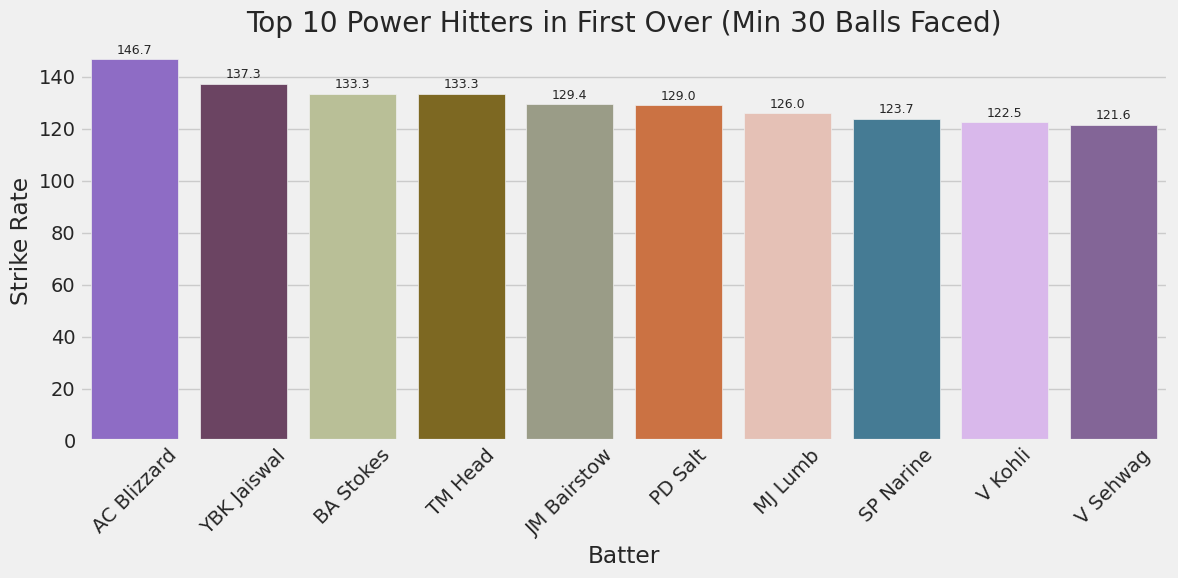

In [ ]:
# Step 1: Filter only first over deliveries
first_over = deli[deli['over'] == 0]

# Step 2: Total runs and balls faced by each batter in first over
fo_runs = first_over.groupby('batter')['batsman_runs'].sum()
fo_balls = first_over.groupby('batter').size()

# Step 3: Filter batters with minimum 30 balls faced
valid_batters = fo_balls[fo_balls >= 30].index

# Step 4: Compute strike rate for these batters
fo_sr = (fo_runs[valid_batters] * 100 / fo_balls[valid_batters]).sort_values(ascending=False).head(10)
fo_sr = fo_sr.reset_index()
fo_sr.columns = ['batter', 'Strike Rate']

# Step 5: Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='batter', y='Strike Rate', data=fo_sr, palette=random_colors(len(fo_sr)), hue='batter', legend=False)
plt.title('Top 10 Power Hitters in First Over (Min 30 Balls Faced)')
plt.xlabel('Batter')
plt.ylabel('Strike Rate')
plt.xticks(rotation=45)

# Add value labels
for i, v in enumerate(fo_sr['Strike Rate']):
  ax.text(i, v + 1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**Toss Win vs Match Win Percentage**

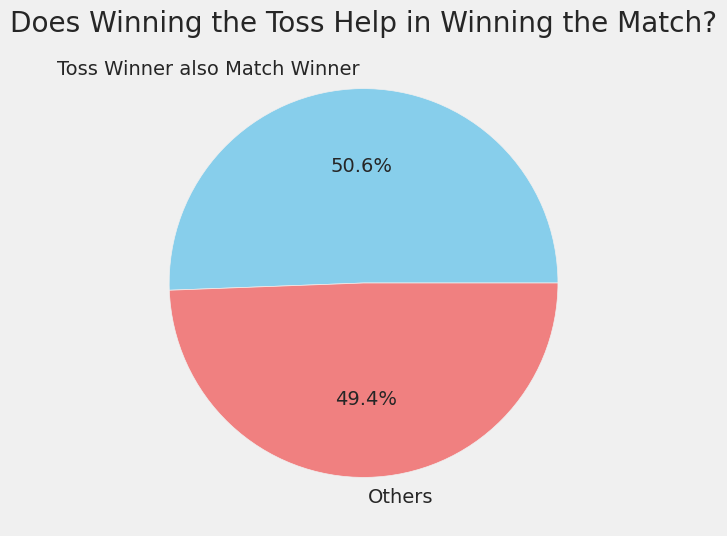

In [ ]:
# Count how many times toss winner won the match
toss_match_win = (mat['toss_winner'] == mat['winner']).sum()
total_matches = mat.shape[0]

# Calculate percentage
percent = (toss_match_win / total_matches) * 100

# Plot
plt.figure(figsize=(6,6))
plt.pie([percent, 100 - percent], labels=['Toss Winner also Match Winner', 'Others'], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Does Winning the Toss Help in Winning the Match?')
plt.show()


**Top 10 IPL Venues by Number of Matches (Till 2024)**

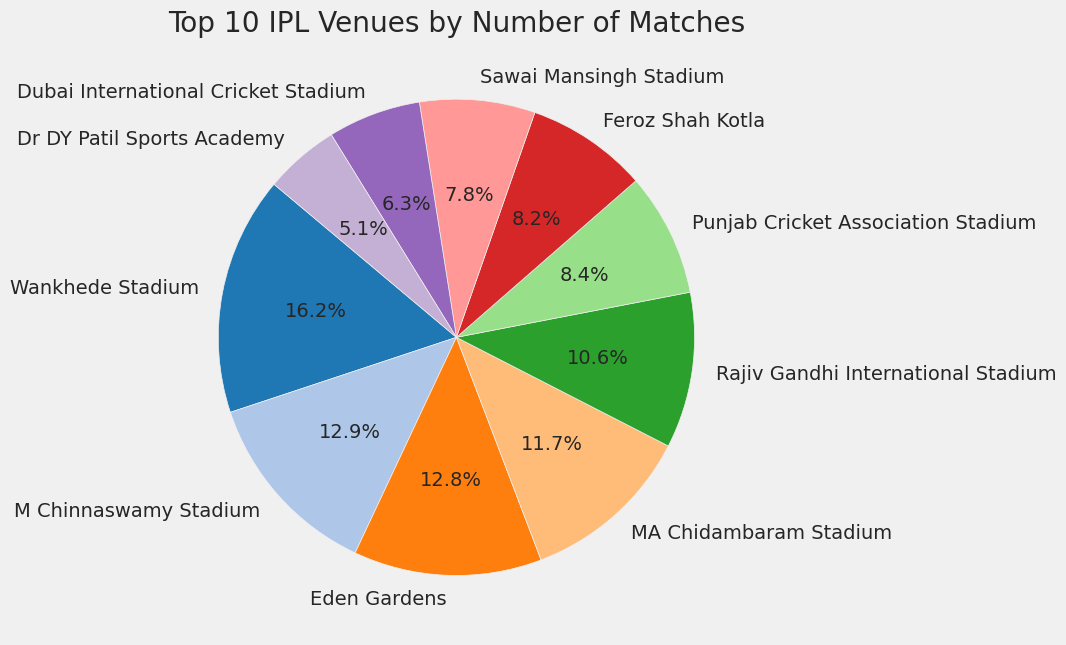

In [ ]:
# Count the number of matches played at each venue
venue_counts = mat['venue'].value_counts().reset_index()

# Rename columns for clarity
venue_counts.columns = ['venue', 'matches']

# Create a pie chart of the top 10 venues based on number of matches hosted
plt.figure(figsize=(10,10))
plt.pie(
    venue_counts['matches'][:10],                   # Top 10 match counts
    labels=venue_counts['venue'][:10],              # Top 10 venues
    autopct='%1.1f%%',                              # Show percentage on pie slices
    startangle=140,                                 # Rotate the start angle for better layout
    colors=plt.cm.tab20.colors                      # Use a colormap for colors
)

# Add chart title
plt.title('Top 10 IPL Venues by Number of Matches')

# Adjust layout to avoid clipping
plt.tight_layout()
plt.show()
